## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap
import joblib

## Load Dataset

In [2]:
data = pd.read_csv('Fraud.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Exploratory Data Analysis (EDA)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

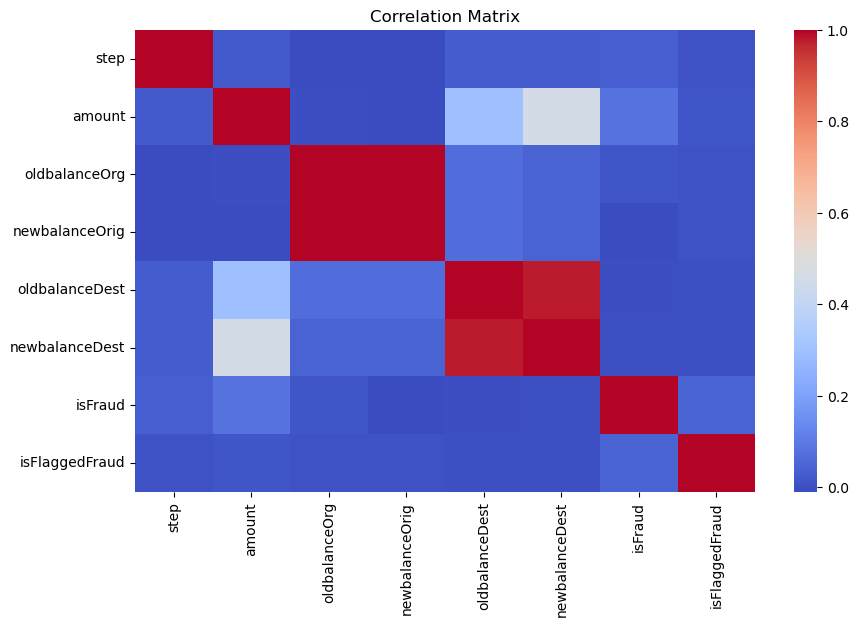

In [6]:
corr = data.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [7]:
data['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

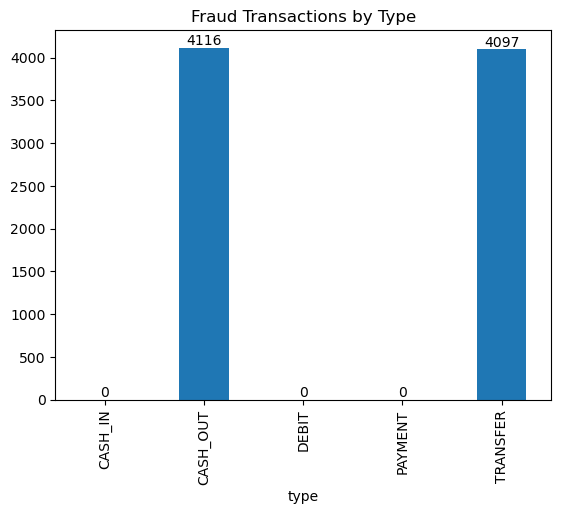

In [8]:
ax = data.groupby('type')['isFraud'].sum().plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Fraud Transactions by Type")
plt.show()

## Feature Engineering

In [9]:
data['orig_balance_error'] = data['oldbalanceOrg'] - data['amount'] - data['newbalanceOrig']

data['dest_balance_error'] = data['oldbalanceDest'] + data['amount'] - data['newbalanceDest']

In [10]:
data['amount_balance_ratio'] = data['amount'] / (data['oldbalanceOrg'] + 1)

In [11]:
data['account_emptied'] = (data['newbalanceOrig'] == 0).astype(int)

In [12]:
data['isMerchant'] = data['nameDest'].str.startswith('M').astype(int)

In [13]:
data['is_transfer'] = (data['type'] == 'TRANSFER').astype(int)

data['is_cashout'] = (data['type'] == 'CASH_OUT').astype(int)

In [14]:
data['day'] = data['step'] // 24

data['hour'] = data['step'] % 24

In [15]:
data['amount_exceeds_balance'] = (
    data['amount'] > data['oldbalanceOrg']
).astype(int)

In [16]:
data['receiver_balance_jump'] = (
    data['newbalanceDest'] > data['oldbalanceDest'] * 10
).astype(int)

In [17]:
data['large_transaction'] = (
    data['amount'] > data['amount'].quantile(0.95)
).astype(int)

In [18]:
data['risk_score'] = (
    data['amount_exceeds_balance']
    + data['receiver_balance_jump']
    + data['account_emptied']
)

In [19]:
data.drop(
    ['nameOrig','nameDest','isFlaggedFraud','step','type'],
    axis=1,
    inplace=True
)

## Define Features and Target

In [20]:
X = data.drop('isFraud', axis=1)

y = data['isFraud']

## Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Handle Imbalanced Data

In [22]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: isFraud
0    5083526
1       6570
Name: count, dtype: int64
After SMOTE: isFraud
0    5083526
1    5083526
Name: count, dtype: int64


## Model Training

In [23]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_resampled, y_train_resampled)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [24]:
rf = RandomForestClassifier(

n_estimators=100,

max_depth=12,

class_weight='balanced',

random_state=42,

n_jobs=-1

)

rf.fit(X_train_resampled,y_train_resampled)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [25]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=10,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_resampled, y_train_resampled)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

## Model Evaluation

In [26]:
print("Logistic Regression")

print(classification_report(y_test, lr_pred))

print("ROC AUC:", roc_auc_score(y_test, lr_prob))


print("\nRandom Forest")

print(classification_report(y_test, rf_pred))

print("ROC AUC:", roc_auc_score(y_test, rf_prob))


print("\nXGBoost")

print(classification_report(y_test, xgb_pred))

print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.24      1.00      0.38      1643

    accuracy                           1.00   1272524
   macro avg       0.62      1.00      0.69   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC AUC: 0.9996627161820335

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.98      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC AUC: 0.9999428159899943

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.99     

## Precision–Recall Curve Analysis

In [27]:
pr_auc = average_precision_score(y_test,rf_prob)

print("PR AUC:",pr_auc)

PR AUC: 0.9987460312505847


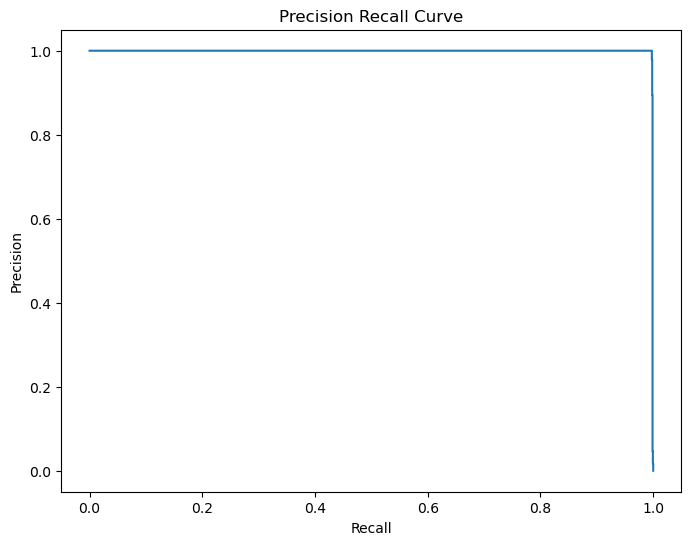

In [28]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

## Confusion Matrix Evaluation

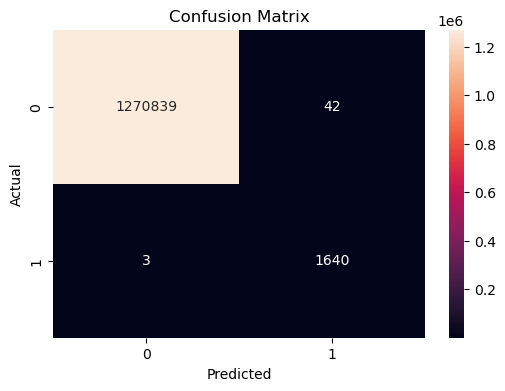

In [29]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Feature Importance Analysis 

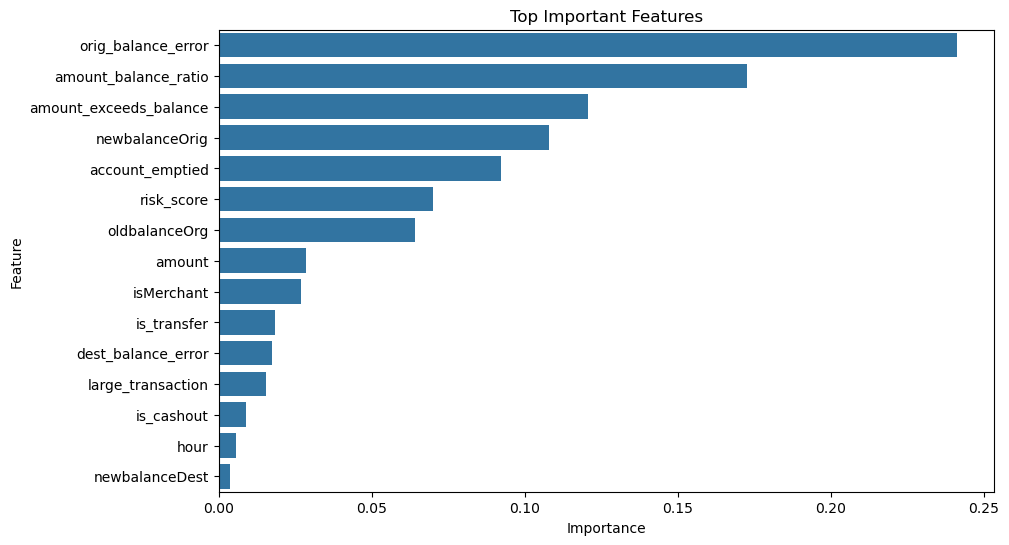

In [30]:
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_imp.head(15)
)

plt.title("Top Important Features")

plt.show()

## Model Explainability using SHAP

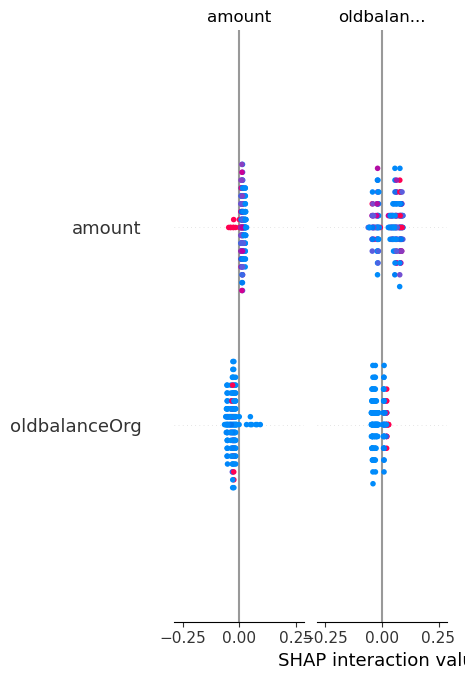

In [34]:
explainer = shap.TreeExplainer(rf)

sample = X_test.sample(200)

shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values,sample)

## Threshold Optimization

In [35]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1,0.9,0.05)

scores = []

for t in thresholds:
    
    preds = (rf_prob > t).astype(int)
    
    score = f1_score(y_test, preds)
    
    scores.append(score)

best_threshold = thresholds[np.argmax(scores)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.8000000000000002


## Model Persistence

In [38]:
joblib.dump(xgb, "fraud_model.pkl")

joblib.dump(X.columns, "model_features.pkl")

print("Model Saved Successfully")

Model Saved Successfully


## Final Model Comparison

In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "ROC_AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.sort_values(by="ROC_AUC", ascending=False)

,Model,ROC_AUC
1,Random Forest,0.999943
2,XGBoost,0.999867
0,Logistic Regression,0.999663


## Final Result

After training Logistic Regression, Random Forest, and XGBoost models, **Random Forest showed the best performance** and was selected as the final model for fraud prediction and deployment.